<a href="https://colab.research.google.com/github/Rakshithbodakuntla/ML_/blob/main/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [4]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [8]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [10]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
99995,True
99996,False
99997,False
99998,False


In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
99994,False
99996,False
99997,False
99998,False


In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['smoking_history'] = le.fit_transform(df['smoking_history'])


<Axes: >

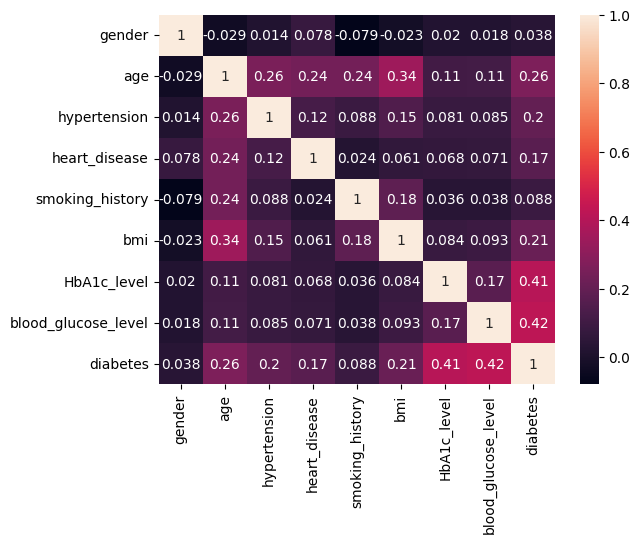

In [19]:
sns.heatmap(df.corr(),annot=True)

In [23]:
x = df[['gender','age','hypertension','heart_disease','smoking_history','bmi','HbA1c_level','blood_glucose_level']]
y = df[['diabetes']]

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [26]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [27]:
lr.predict(x_test)

array([0, 0, 1, ..., 0, 0, 0])

In [30]:
y_test

,diabetes
2547,0
34774,0
71084,1
50584,0
80788,0
...,...
19314,0
17624,0
8673,0
37062,0


In [28]:
lr.score(x_train,y_train)

0.951830568412294

In [31]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [32]:
dt.predict(x_test)

array([0, 0, 1, ..., 0, 0, 0])

In [38]:
dt.score(x_test,y_test)

0.946801872074883

In [34]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

In [35]:
rf.predict(x_test)

array([0, 0, 1, ..., 0, 0, 0])

In [37]:
rf.score(x_test,y_test)

0.9684867394695788

In [39]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [40]:
knn.predict(x_test)

array([0, 0, 1, ..., 0, 0, 0])

In [41]:
knn.score(x_test,y_test)

0.9514820592823713

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
lr_acc = accuracy_score(y_test,lr.predict(x_test))
dt_acc = accuracy_score(y_test,dt.predict(x_test))
rf_acc = accuracy_score(y_test,rf.predict(x_test))
knn_acc = accuracy_score(y_test,knn.predict(x_test))

print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)
print("K-Nearest Neighbors Accuracy:", knn_acc)

lr_pre = precision_score(y_test,lr.predict(x_test))
dt_pre = precision_score(y_test,dt.predict(x_test))
rf_pre = precision_score(y_test,rf.predict(x_test))
knn_pre = precision_score(y_test,knn.predict(x_test))

print("\nLogistic Regression Precision:", lr_pre)
print("Decision Tree Precision:", dt_pre)
print("Random Forest Precision:", rf_pre)
print("K-Nearest Neighbors Precision:", knn_pre)

lr_rec = recall_score(y_test,lr.predict(x_test))
dt_rec = recall_score(y_test,dt.predict(x_test))
rf_rec = recall_score(y_test,rf.predict(x_test))
knn_rec = recall_score(y_test,knn.predict(x_test))
print("")
print("Logistic Regression Recall:", lr_rec)
print("Decision Tree Recall:", dt_rec)
print("Random Forest Recall:", rf_rec)
print("K-Nearest Neighbors Recall:", knn_rec)

lr_f1 = f1_score(y_test,lr.predict(x_test))
dt_f1 = f1_score(y_test,dt.predict(x_test))
rf_f1 = f1_score(y_test,rf.predict(x_test))
knn_f1 = f1_score(y_test,knn.predict(x_test))

print("\nLogistic Regression F1 Score:", lr_f1)
print("Decision Tree F1 Score:", dt_f1)
print("Random Forest F1 Score:", rf_f1)
print("K-Nearest Neighbors F1 Score:", knn_f1)


Logistic Regression Accuracy: 0.9509100364014561
Decision Tree Accuracy: 0.946801872074883
Random Forest Accuracy: 0.9684867394695788
K-Nearest Neighbors Accuracy: 0.9514820592823713

Logistic Regression Precision: 0.8076009501187649
Decision Tree Precision: 0.6915477497255763
Random Forest Precision: 0.94351630867144
K-Nearest Neighbors Precision: 0.8627992633517495

Logistic Regression Recall: 0.5926786751888437
Decision Tree Recall: 0.7321324811156305
Random Forest Recall: 0.6891342242882045
K-Nearest Neighbors Recall: 0.5444509006391632

Logistic Regression F1 Score: 0.6836461126005362
Decision Tree F1 Score: 0.7112616426756986
Random Forest F1 Score: 0.796507723304231
K-Nearest Neighbors F1 Score: 0.6676166726042038


In [50]:
confusion_matrix(y_test,lr.predict(x_test))

array([[17266,   243],
       [  701,  1020]])

In [51]:
confusion_matrix(y_test,dt.predict(x_test))

array([[16947,   562],
       [  461,  1260]])

In [52]:
confusion_matrix(y_test,rf.predict(x_test))

array([[17438,    71],
       [  535,  1186]])

In [55]:
confusion_matrix(y_test, knn.predict(x_test))

array([[17360,   149],
       [  784,   937]])

<Axes: >

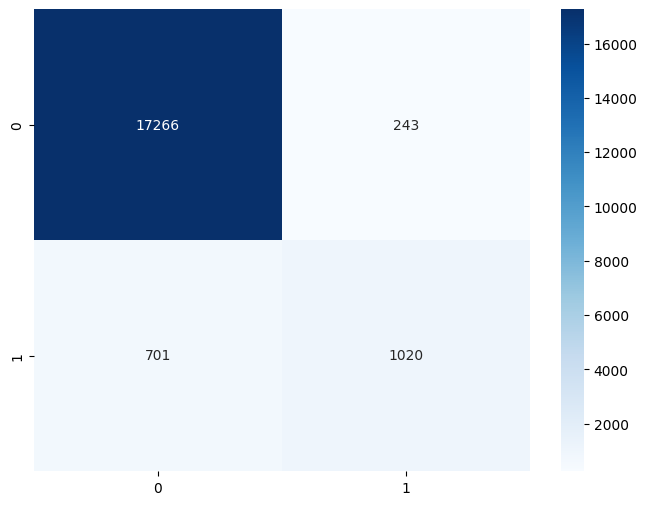

In [61]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test,lr.predict(x_test)), annot=True, fmt='d', cmap='Blues')

In [65]:
comparision = pd.DataFrame({'Accuracy':[lr_acc,dt_acc,rf_acc,knn_acc],'Precision':[lr_pre,dt_pre,rf_pre,knn_acc],'Recall':[lr_rec,dt_rec,rf_rec,knn_rec],'F1 Score':[lr_f1,dt_f1,rf_f1,knn_f1]})

In [70]:
comparision

,Accuracy,Precision,Recall,F1 Score
0,0.950910,0.807601,0.592679,0.683646
1,0.946802,0.691548,0.732132,0.711262
2,0.968487,0.943516,0.689134,0.796508
3,0.951482,0.951482,0.544451,0.667617
